In [74]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/carvana-image-masking-challenge/train_masks.zip
/kaggle/input/carvana-image-masking-challenge/29bb3ece3180_11.jpg
/kaggle/input/carvana-image-masking-challenge/train_masks.csv.zip
/kaggle/input/carvana-image-masking-challenge/train.zip
/kaggle/input/carvana-image-masking-challenge/metadata.csv.zip
/kaggle/input/carvana-image-masking-challenge/sample_submission.csv.zip
/kaggle/input/carvana-image-masking-challenge/test.zip
/kaggle/input/carvana-image-masking-challenge/test_hq.zip
/kaggle/input/carvana-image-masking-challenge/train_hq.zip
/kaggle/input/d/uddavrajbhandari/carvana-image-masking-challenge/carvana-image-masking-challenge


In [75]:
import copy
import os
import random
import shutil
import zipfile
from math import atan2, cos, sin, sqrt, pi, log

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from PIL import Image
from numpy import linalg as LA
from torch import optim, nn
from torch.utils.data import DataLoader, random_split
from torch.utils.data.dataset import Dataset
from torchvision import transforms
from tqdm import tqdm

In [6]:
class DoubleConv(nn.Module): # Fearure Extraction Block
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv_op = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv_op(x)

In [7]:
class DownSample(nn.Module): # encoder block
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = DoubleConv(in_channels, out_channels) # to learn features
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # downsample by a factor of 2

    def forward(self, x):
        down = self.conv(x) # features before pooling
        p = self.pool(down) # pooled features

        return down, p

In [8]:
class UpSample(nn.Module): # decoder block with skip connection
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels//2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        x = torch.cat([x1, x2], 1) # skip connections
        return self.conv(x)

In [10]:
class UNet(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        # contracting path(encoder)
        self.down_convolution_1 = DownSample(in_channels, 64)
        self.down_convolution_2 = DownSample(64, 128)
        self.down_convolution_3 = DownSample(128, 256)
        self.down_convolution_4 = DownSample(256, 512)
        # Each step doubles the channels and halves the spatial resolution using pooling

        self.bottle_neck = DoubleConv(512, 1024) # The deepest part of the network with the highest number of channels.
        # expanding path (decoder)
        self.up_convolution_1 = UpSample(1024, 512)
        self.up_convolution_2 = UpSample(512, 256)
        self.up_convolution_3 = UpSample(256, 128)
        self.up_convolution_4 = UpSample(128, 64)

        self.out = nn.Conv2d(in_channels=64, out_channels=num_classes, kernel_size=1)

    def forward(self, x):
      # progressively downsample → p1 → p4
        down_1, p1 = self.down_convolution_1(x)
        down_2, p2 = self.down_convolution_2(p1)
        down_3, p3 = self.down_convolution_3(p2)
        down_4, p4 = self.down_convolution_4(p3)

        b = self.bottle_neck(p4) # deep feature extraction.
      #  upsample & concatenate with encoder outputs (down_4 → down_1).
        up_1 = self.up_convolution_1(b, down_4)
        up_2 = self.up_convolution_2(up_1, down_3)
        up_3 = self.up_convolution_3(up_2, down_2)
        up_4 = self.up_convolution_4(up_3, down_1)

        out = self.out(up_4) #map output to num_classes
        return out

In [80]:
input_image = torch.rand((1,3,512,512))
model = UNet(3,10)
output = model(input_image)
print(output.size())
# You should get torch.Size([1, 10, 512, 512]) as a result

torch.Size([1, 10, 512, 512])


In [81]:
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import os

class CarvanaDataset(Dataset):
    def __init__(self, root_path, limit=None):
        self.root_path = root_path
        self.limit = limit

        # Full paths to images and masks
        self.images = sorted([os.path.join(root_path, "train", f) for f in os.listdir(os.path.join(root_path, "train"))])[:limit]
        self.masks = sorted([os.path.join(root_path, "train_masks", f) for f in os.listdir(os.path.join(root_path, "train_masks"))])[:limit]

        # Transformations
        self.transform = transforms.Compose([
            transforms.Resize((512, 512)),
            transforms.ToTensor()
        ])

        # Auto set limit if None
        if self.limit is None:
            self.limit = len(self.images)

    def __getitem__(self, index):
        img_path = self.images[index]  #  define img_path
        mask_path = self.masks[index]

        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        img = self.transform(img)
        mask = self.transform(mask)

        return img, mask, img_path  #  return the path

    def __len__(self):
        return min(len(self.images), self.limit)


In [82]:
import os

print(os.listdir("/kaggle/input/carvana-image-masking-challenge"))


['train_masks.zip', '29bb3ece3180_11.jpg', 'train_masks.csv.zip', 'train.zip', 'metadata.csv.zip', 'sample_submission.csv.zip', 'test.zip', 'test_hq.zip', 'train_hq.zip']


In [83]:
print(os.listdir("../input/carvana-image-masking-challenge/"))

DATASET_DIR = '../input/carvana-image-masking-challenge/'
WORKING_DIR = '/kaggle/working/'

['train_masks.zip', '29bb3ece3180_11.jpg', 'train_masks.csv.zip', 'train.zip', 'metadata.csv.zip', 'sample_submission.csv.zip', 'test.zip', 'test_hq.zip', 'train_hq.zip']


In [84]:
if len(os.listdir(WORKING_DIR)) <= 1:

    with zipfile.ZipFile(DATASET_DIR + 'train.zip', 'r') as zip_file:
        zip_file.extractall(WORKING_DIR)

    with zipfile.ZipFile(DATASET_DIR + 'train_masks.zip', 'r') as zip_file:
        zip_file.extractall(WORKING_DIR)
    
    print(
        len(os.listdir(WORKING_DIR + 'train')),
        len(os.listdir(WORKING_DIR + 'train_masks'))
    )

In [85]:
train_dataset = CarvanaDataset(WORKING_DIR)

generator = torch.Generator().manual_seed(25) # Ensures deterministic data shuffling for reproducibility

In [86]:
train_dataset, test_dataset = random_split(train_dataset, [0.8, 0.2], generator=generator)
test_dataset, val_dataset = random_split(test_dataset, [0.5, 0.5], generator=generator)

In [87]:
device = "cuda" if torch.cuda.is_available() else "cpu"

if device == "cuda":
    num_workers = torch.cuda.device_count() * 4

In [88]:
LEARNING_RATE = 3e-4
BATCH_SIZE = 8

train_dataloader = DataLoader(dataset=train_dataset,
                              num_workers=num_workers, pin_memory=False,
                              batch_size=BATCH_SIZE,
                              shuffle=True)
val_dataloader = DataLoader(dataset=val_dataset,
                            num_workers=num_workers, pin_memory=False,
                            batch_size=BATCH_SIZE,
                            shuffle=True)

test_dataloader = DataLoader(dataset=test_dataset,
                            num_workers=num_workers, pin_memory=False,
                            batch_size=BATCH_SIZE,
                            shuffle=True)

model = UNet(in_channels=3, num_classes=1).to(device)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
criterion = nn.BCEWithLogitsLoss()

In [89]:
def dice_coefficient(prediction, target, epsilon=1e-07):
    prediction_copy = prediction.clone()

    prediction_copy[prediction_copy < 0] = 0
    prediction_copy[prediction_copy > 0] = 1

    intersection = abs(torch.sum(prediction_copy * target))
    union = abs(torch.sum(prediction_copy) + torch.sum(target))
    dice = (2. * intersection + epsilon) / (union + epsilon)
    
    return dice

In [90]:
EPOCHS = 6

train_losses = []
train_dcs = []
val_losses = []
val_dcs = []

for epoch in tqdm(range(EPOCHS)):
    model.train()
    train_running_loss = 0
    train_running_dc = 0
    
    for idx, img_mask in enumerate(tqdm(train_dataloader, position=0, leave=True)):
        img = img_mask[0].float().to(device)
        mask = img_mask[1].float().to(device)
        
        y_pred = model(img)
        optimizer.zero_grad()
        
        dc = dice_coefficient(y_pred, mask)
        loss = criterion(y_pred, mask)
        
        train_running_loss += loss.item()
        train_running_dc += dc.item()

        loss.backward()
        optimizer.step()

    train_loss = train_running_loss / (idx + 1)
    train_dc = train_running_dc / (idx + 1)
    
    train_losses.append(train_loss)
    train_dcs.append(train_dc)

    model.eval()
    val_running_loss = 0
    val_running_dc = 0
    
    with torch.no_grad():
        for idx, img_mask in enumerate(tqdm(val_dataloader, position=0, leave=True)):
            img = img_mask[0].float().to(device)
            mask = img_mask[1].float().to(device)

            y_pred = model(img)
            loss = criterion(y_pred, mask)
            dc = dice_coefficient(y_pred, mask)
            
            val_running_loss += loss.item()
            val_running_dc += dc.item()

        val_loss = val_running_loss / (idx + 1)
        val_dc = val_running_dc / (idx + 1)
    
    val_losses.append(val_loss)
    val_dcs.append(val_dc)

    print("-" * 30)
    print(f"Training Loss EPOCH {epoch + 1}: {train_loss:.4f}")
    print(f"Training DICE EPOCH {epoch + 1}: {train_dc:.4f}")
    print("\n")
    print(f"Validation Loss EPOCH {epoch + 1}: {val_loss:.4f}")
    print(f"Validation DICE EPOCH {epoch + 1}: {val_dc:.4f}")
    print("-" * 30)

# Saving the model
torch.save(model.state_dict(), 'my_checkpoint.pth')

 17%|█▋        | 1/6 [06:54<34:31, 414.28s/it]

------------------------------
Training Loss EPOCH 1: 0.1326
Training DICE EPOCH 1: 0.8439


Validation Loss EPOCH 1: 0.0306
Validation DICE EPOCH 1: 0.9716
------------------------------


 33%|███▎      | 2/6 [13:49<27:38, 414.54s/it]

------------------------------
Training Loss EPOCH 2: 0.0303
Training DICE EPOCH 2: 0.9722


Validation Loss EPOCH 2: 0.0251
Validation DICE EPOCH 2: 0.9767
------------------------------


 50%|█████     | 3/6 [20:43<20:44, 414.68s/it]

...

------------------------------
Training Loss EPOCH 4: 0.0306
Training DICE EPOCH 4: 0.9701


Validation Loss EPOCH 4: 0.0164
Validation DICE EPOCH 4: 0.9847
------------------------------


 83%|████████▎ | 5/6 [34:32<06:54, 414.41s/it]

------------------------------
Training Loss EPOCH 5: 0.0140
Training DICE EPOCH 5: 0.9871


Validation Loss EPOCH 5: 0.0124
Validation DICE EPOCH 5: 0.9884
------------------------------


100%|██████████| 6/6 [41:26<00:00, 414.44s/it]


------------------------------
Training Loss EPOCH 6: 0.0112
Training DICE EPOCH 6: 0.9896


Validation Loss EPOCH 6: 0.0100
Validation DICE EPOCH 6: 0.9906
------------------------------


/tmp/ipykernel_35/3950988869.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


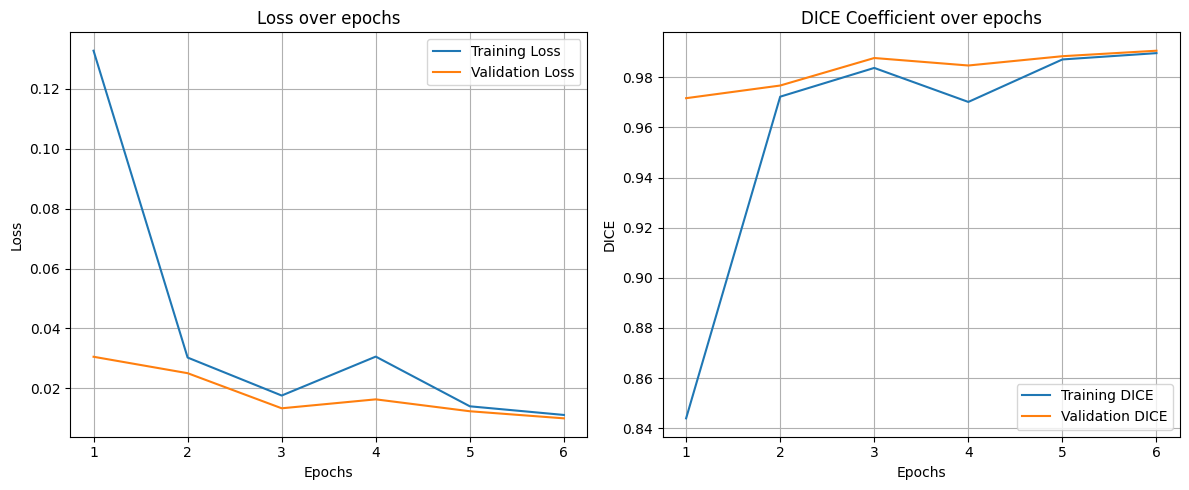

In [91]:
epochs_list = list(range(1, EPOCHS + 1))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_list, train_losses, label='Training Loss')
plt.plot(epochs_list, val_losses, label='Validation Loss')
plt.xticks(ticks=list(range(1, EPOCHS + 1, 1))) 
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid()
plt.tight_layout()

plt.legend()


plt.subplot(1, 2, 2)
plt.plot(epochs_list, train_dcs, label='Training DICE')
plt.plot(epochs_list, val_dcs, label='Validation DICE')
plt.xticks(ticks=list(range(1, EPOCHS + 1, 1)))  
plt.title('DICE Coefficient over epochs')
plt.xlabel('Epochs')
plt.ylabel('DICE')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

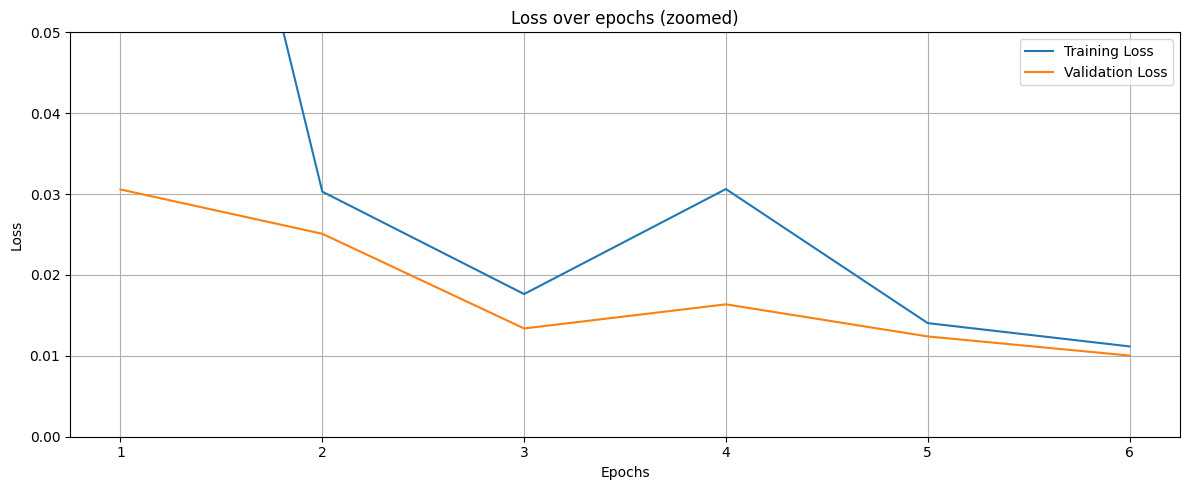

In [92]:
epochs_list = list(range(1, EPOCHS + 1))

plt.figure(figsize=(12, 5))
plt.plot(epochs_list, train_losses, label='Training Loss')
plt.plot(epochs_list, val_losses, label='Validation Loss')
plt.xticks(ticks=list(range(1, EPOCHS + 1, 1))) 
plt.ylim(0, 0.05)
plt.title('Loss over epochs (zoomed)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid()
plt.tight_layout()

plt.legend()
plt.show()

In [93]:
model_pth = '/kaggle/working/my_checkpoint.pth'
trained_model = UNet(in_channels=3, num_classes=1).to(device)
trained_model.load_state_dict(torch.load(model_pth, map_location=torch.device(device)))

<All keys matched successfully>

In [94]:
test_running_loss = 0
test_running_dc = 0

with torch.no_grad():
    for idx, img_mask in enumerate(tqdm(test_dataloader, position=0, leave=True)):
        img = img_mask[0].float().to(device)
        mask = img_mask[1].float().to(device)

        y_pred = trained_model(img)
        loss = criterion(y_pred, mask)
        dc = dice_coefficient(y_pred, mask)

        test_running_loss += loss.item()
        test_running_dc += dc.item()

    test_loss = test_running_loss / (idx + 1)
    test_dc = test_running_dc / (idx + 1)


100%|██████████| 64/64 [00:20<00:00,  3.16it/s]


In [95]:
def random_images_inference(image_tensors, mask_tensors, image_paths, model_pth, device):
    model = UNet(in_channels=3, num_classes=1).to(device)
    model.load_state_dict(torch.load(model_pth, map_location=torch.device(device)))

    transform = transforms.Compose([
        transforms.Resize((512, 512))
    ])

    # Iterate for the images, masks and paths
    for image_pth, mask_pth, image_paths in zip(image_tensors, mask_tensors, image_paths):
        # Load the image
        img = transform(image_pth)
        
        # Predict the imagen with the model
        pred_mask = model(img.unsqueeze(0))
        pred_mask = pred_mask.squeeze(0).permute(1,2,0)
        
        # Load the mask to compare
        mask = transform(mask_pth).permute(1, 2, 0).to(device)
        
        print(f"Image: {os.path.basename(image_paths)}, DICE coefficient: {round(float(dice_coefficient(pred_mask, mask)),5)}")
        
        # Show the images
        img = img.cpu().detach().permute(1, 2, 0)
        pred_mask = pred_mask.cpu().detach()
        pred_mask[pred_mask < 0] = 0
        pred_mask[pred_mask > 0] = 1
        
        plt.figure(figsize=(15, 16))
        plt.subplot(131), plt.imshow(img), plt.title("original")
        plt.subplot(132), plt.imshow(pred_mask, cmap="gray"), plt.title("predicted")
        plt.subplot(133), plt.imshow(mask, cmap="gray"), plt.title("mask")
        plt.show()

In [96]:
n = 10

image_tensors = []
mask_tensors = []
image_paths = []

for _ in range(n):
    random_index = random.randint(0, len(test_dataloader.dataset) - 1)
    random_sample = test_dataloader.dataset[random_index]

    image_tensors.append(random_sample[0])  
    mask_tensors.append(random_sample[1]) 
    image_paths.append(random_sample[2])

Image: 6ae670e86620_03.jpg, DICE coefficient: 0.98966


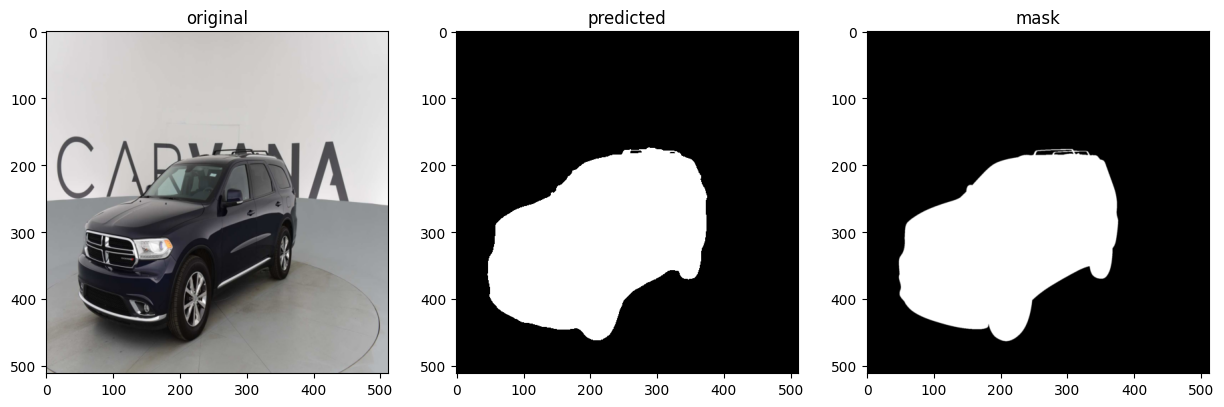

Image: 6e016b8b3617_06.jpg, DICE coefficient: 0.99327


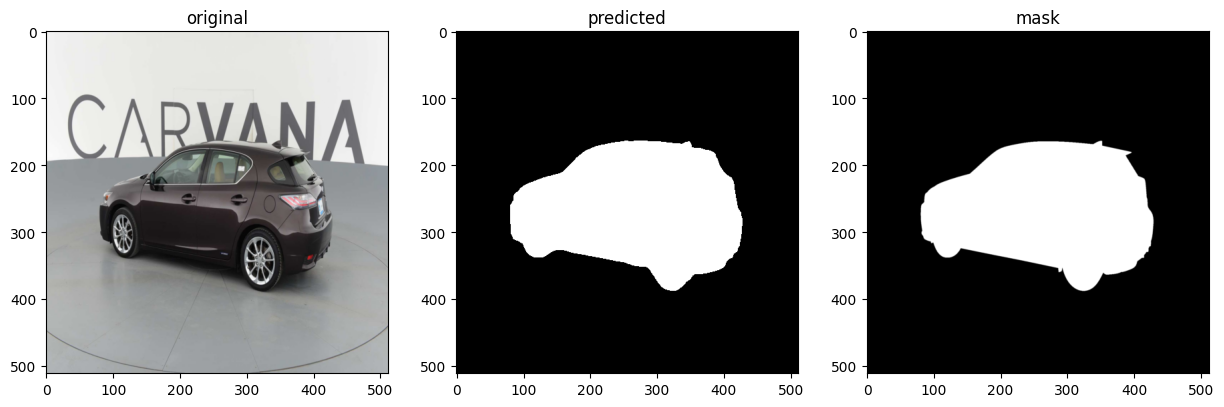

Image: d0dab700c896_13.jpg, DICE coefficient: 0.99113


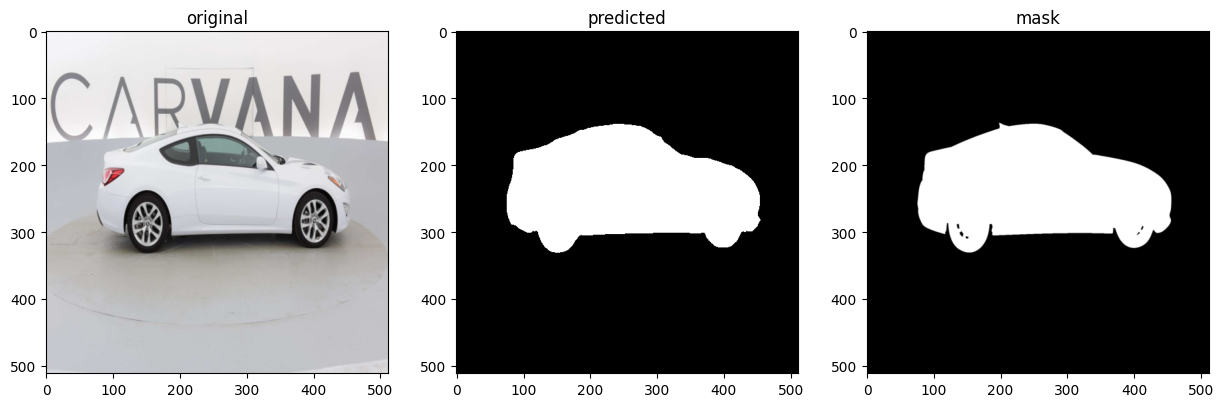

Image: 1ba84b81628e_08.jpg, DICE coefficient: 0.98773


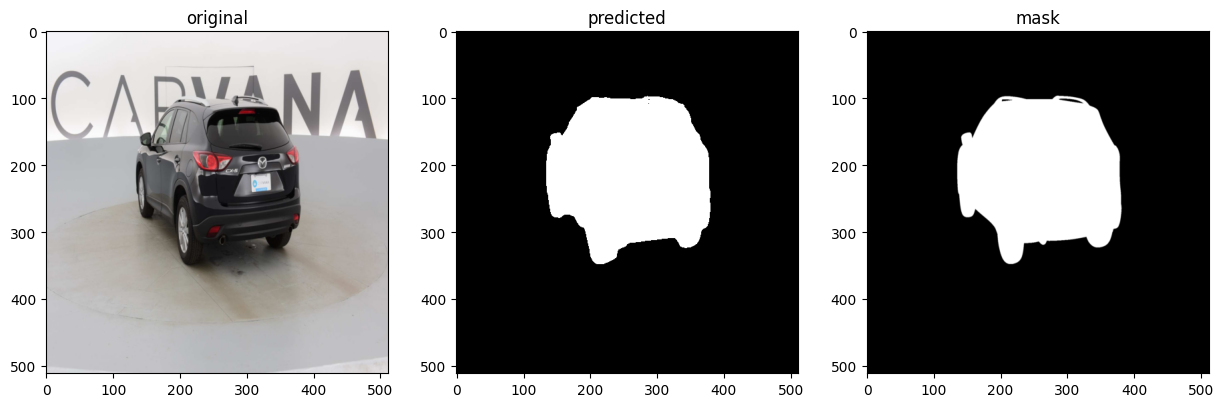

Image: 3a7a8f03e713_05.jpg, DICE coefficient: 0.98701


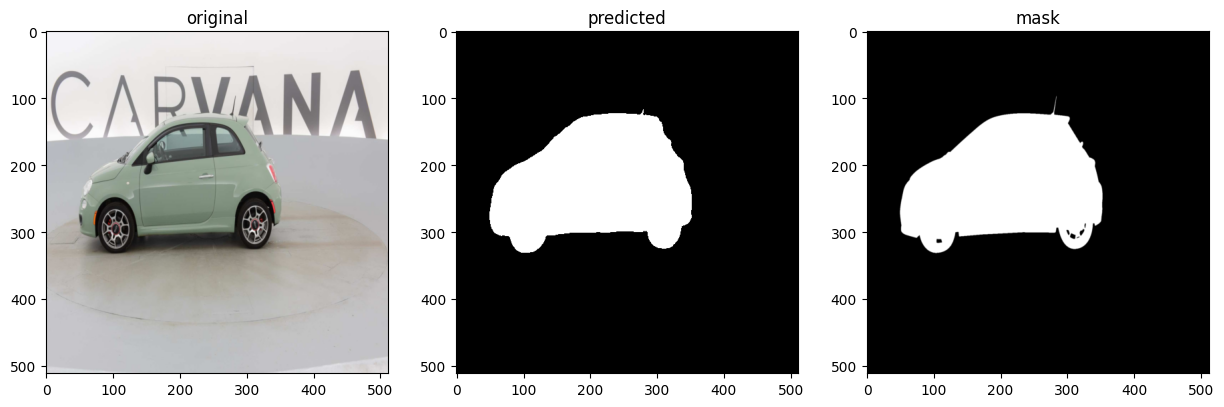

Image: 4baf50a3d8c2_03.jpg, DICE coefficient: 0.9894


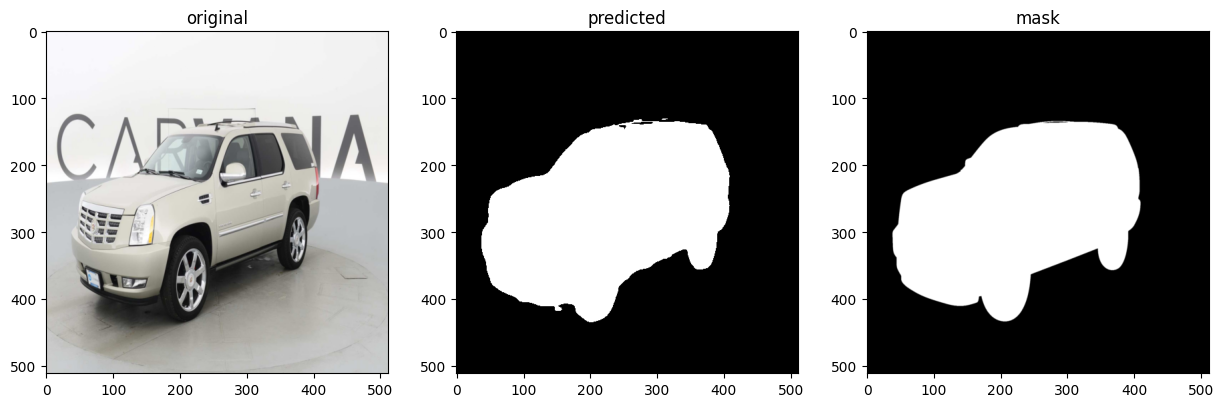

Image: 364923a5002f_04.jpg, DICE coefficient: 0.992


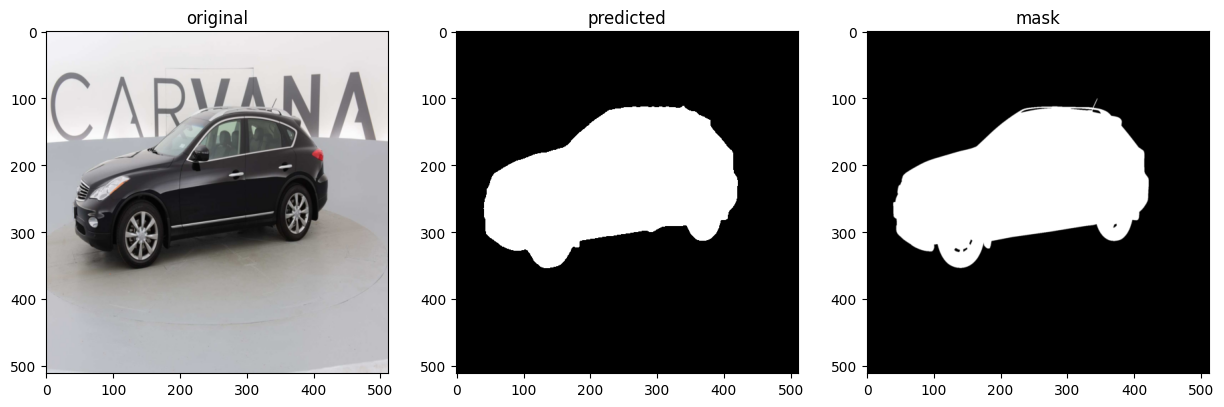

Image: 364fd5fd7569_01.jpg, DICE coefficient: 0.98861


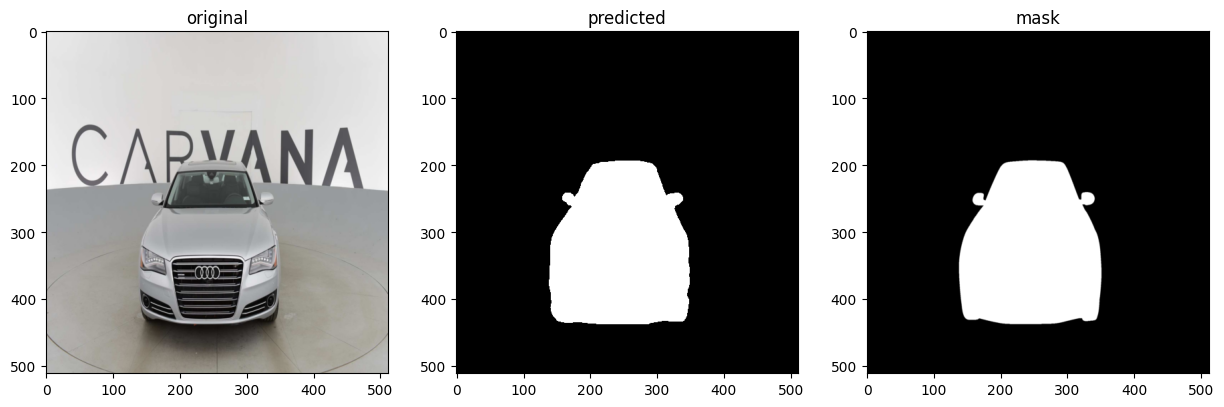

Image: 293a0fa72e5b_05.jpg, DICE coefficient: 0.9914


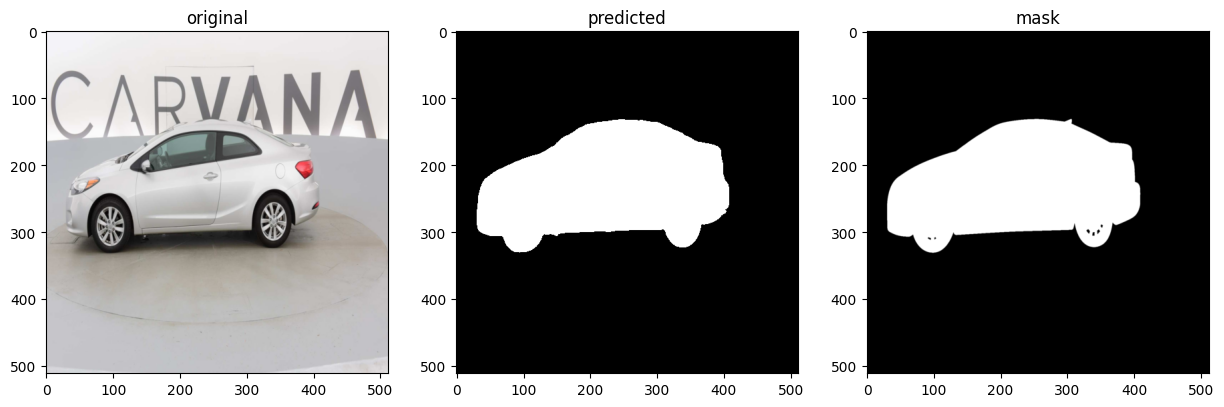

Image: d8216041ffa9_07.jpg, DICE coefficient: 0.99372


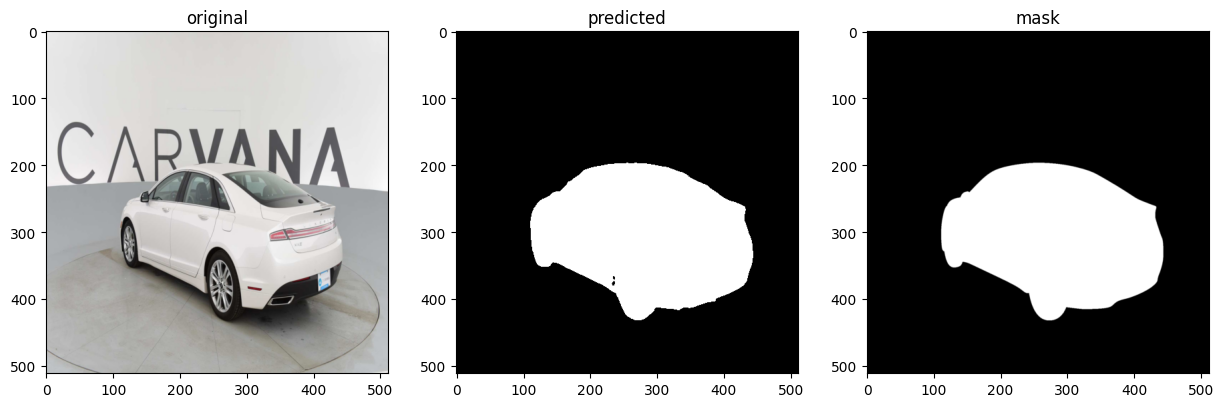

In [ ]:
model_path = '/kaggle/working/my_checkpoint.pth'

random_images_inference(image_tensors, mask_tensors, image_paths, model_path, device="cpu")


## Abdominal organ segmentation dataset


### abdominal organ segmentation dataset


In [1]:
import kagglehub as kh
from pathlib import Path
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn as nn
import torch.optim as optim
from albumentations import Compose, Resize, Normalize
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

/usr/local/lib/python3.11/dist-packages/albumentations/check_version.py:107: UserWarning: Error fetching version info <urlopen error [Errno -3] Temporary failure in name resolution>
  data = fetch_version_info()


In [2]:
import kagglehub as kh
from pathlib import Path

# ------------------------------
# 1. Download the Dataset
# ------------------------------
local_path = kh.dataset_download("monirulhaquebracu/abdominal-organ-segmentation-dataset")
print("Dataset downloaded to:", local_path)

# ------------------------------
# 2. Define Train and Test Paths
# ------------------------------
train_root = Path(local_path) / "split_organized" / "train"
test_root = Path(local_path) / "split_organized" / "test"

print("Train folder path:", train_root)
print("Test folder path:", test_root)


Dataset downloaded to: /kaggle/input/abdominal-organ-segmentation-dataset
Train folder path: /kaggle/input/abdominal-organ-segmentation-dataset/split_organized/train
Test folder path: /kaggle/input/abdominal-organ-segmentation-dataset/split_organized/test


In [3]:
class UNet(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        # contracting path(encoder)
        self.down_convolution_1 = DownSample(in_channels, 64)
        self.down_convolution_2 = DownSample(64, 128)
        self.down_convolution_3 = DownSample(128, 256)
        self.down_convolution_4 = DownSample(256, 512)
        # Each step doubles the channels and halves the spatial resolution using pooling

        self.bottle_neck = DoubleConv(512, 1024) # The deepest part of the network with the highest number of channels.
        # expanding path (decoder)
        self.up_convolution_1 = UpSample(1024, 512)
        self.up_convolution_2 = UpSample(512, 256)
        self.up_convolution_3 = UpSample(256, 128)
        self.up_convolution_4 = UpSample(128, 64)

        self.out = nn.Conv2d(in_channels=64, out_channels=num_classes, kernel_size=1)

    def forward(self, x):
      # progressively downsample → p1 → p4
        down_1, p1 = self.down_convolution_1(x)
        down_2, p2 = self.down_convolution_2(p1)
        down_3, p3 = self.down_convolution_3(p2)
        down_4, p4 = self.down_convolution_4(p3)

        b = self.bottle_neck(p4) # deep feature extraction.
      #  upsample & concatenate with encoder outputs (down_4 → down_1).
        up_1 = self.up_convolution_1(b, down_4)
        up_2 = self.up_convolution_2(up_1, down_3)
        up_3 = self.up_convolution_3(up_2, down_2)
        up_4 = self.up_convolution_4(up_3, down_1)

        out = self.out(up_4) #map output to num_classes
        return out

In [4]:
class OrganSegDataset(Dataset):
    def __init__(self, root_dir, transforms=None, num_classes=6):
        self.root_dir = Path(root_dir)
        self.sample_dirs = list(self.root_dir.glob("image*"))
        self.transforms = transforms
        self.num_classes = num_classes

    def __len__(self):
        return len(self.sample_dirs)

    def __getitem__(self, idx):
        sample_dir = self.sample_dirs[idx]
        img_path = sample_dir / "images"
        mask_path = sample_dir / "masks"

        # Load image
        image_file = list(img_path.glob("*.png"))[0]  # Assuming 1 image per folder
        image = Image.open(image_file).convert("RGB")

        # Initialize empty mask
        mask = np.zeros((image.height, image.width), dtype=np.uint8)

        # Assign class labels to each organ mask
        label_map = {
            "abdomen": 1,
            "colon": 2,
            "liver": 3,
            "spleen": 4,
            "pancreas": 5
            # add more if needed
        }

        for mask_file in mask_path.glob("*.png"):
            organ_name = mask_file.stem.split("_")[-1].lower()
            if organ_name in label_map:
                organ_mask = Image.open(mask_file).convert("L")
                organ_mask = np.array(organ_mask)
                mask[organ_mask > 0] = label_map[organ_name]

        if self.transforms:
            augmented = self.transforms(image=np.array(image), mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        return image, mask.long()



In [13]:
import torch.nn.functional as F

def dice_score(preds, targets, num_classes=6, epsilon=1e-6):
    preds = torch.argmax(preds, dim=1)  # shape: (B, H, W)
    dice = 0.0
    valid_classes = 0

    for cls in range(1, num_classes):  # assuming 0 is background
        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()

        intersection = (pred_cls * target_cls).sum()
        total = pred_cls.sum() + target_cls.sum()

        if total > 0:
            dice += (2. * intersection + epsilon) / (total + epsilon)
            valid_classes += 1

    return dice / valid_classes if valid_classes > 0 else torch.tensor(0.0, device=preds.device)



# ------------------------------
# 5. Transforms
# ------------------------------
transform = Compose([
    Resize(256, 256),
    Normalize(),
    ToTensorV2()
])

from pathlib import Path

# ✅ Set correct dataset root path
root = Path("/kaggle/input/abdominal-organ-segmentation-dataset/split_organized")

# ------------------------------
# 6. Load Dataset
# ------------------------------
train_dataset = OrganSegDataset(root / "train", transforms=transform, num_classes=6)
val_dataset = OrganSegDataset(root / "test", transforms=transform, num_classes=6)

# ✅ Check number of samples (optional debug)
print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4)




Train samples: 1144
Val samples: 286


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Safe model init
model = UNet(in_channels=3, num_classes=6).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [10]:
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path


/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Unique GT labels: tensor([0, 2, 3])
Unique predicted labels: tensor([0])
Epoch 1:
  Train Loss: 0.3912 | Dice: 0.0013
  Val   Loss: 0.2478 | Dice: 0.0000
Unique GT labels: tensor([0, 2, 3])
Unique predicted labels: tensor([0])
Epoch 2:
  Train Loss: 0.2152 | Dice: 0.0000
  Val   Loss: 0.2335 | Dice: 0.0000
Unique GT labels: tensor([0, 2, 3])
Unique predicted labels: tensor([0])
Epoch 3:
  Train Loss: 0.2066 | Dice: 0.0000
  Val   Loss: 0.2158 | Dice: 0.0000
Unique GT labels: tensor([0, 2, 3])
Unique predicted labels: tensor([0])
Epoch 4:
  Train Loss: 0.1963 | Dice: 0.0000
  Val   Loss: 0.2057 | Dice: 0.0000
Unique GT labels: tensor([0, 2, 3])
Unique predicted labels: tensor([0])
Epoch 5:
  Train Loss: 0.1903 | Dice: 0.0000
  Val   Loss: 0.2095 | Dice: 0.0000
Unique GT labels: tensor([0, 2, 3])
Unique predicted labels: tensor([0])
Epoch 6:
  Train Loss: 0.1872 | Dice: 0.0000
  Val   Loss: 0.1963 | Dice: 0.0000
Unique GT labels: tensor([0, 2, 3])
Unique predicted labels: tensor([0])
Epo

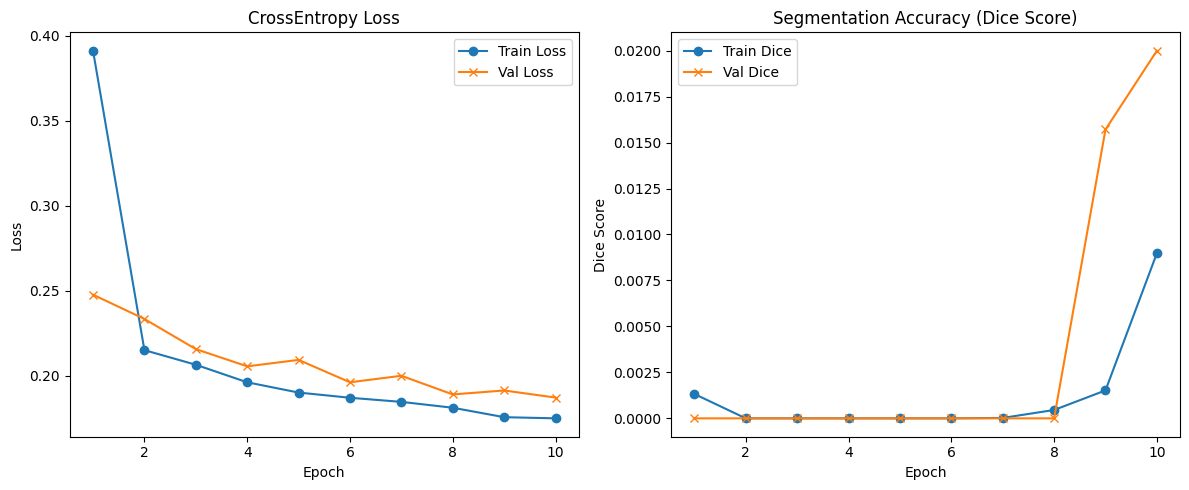

In [15]:
%matplotlib inline

train_losses, val_losses = [], []
train_dice_scores, val_dice_scores = [], []

for epoch in range(10):
    # ----- TRAINING -----
    model.train()
    running_loss, running_dice = 0, 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)

        loss = criterion(preds, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_dice += dice_score(preds, masks).cpu().item()

    avg_train_loss = running_loss / len(train_loader)
    avg_train_dice = running_dice / len(train_loader)

    train_losses.append(avg_train_loss)
    train_dice_scores.append(avg_train_dice)

    # ----- VALIDATION -----
    model.eval()
    val_loss, val_dice = 0, 0
    with torch.no_grad():
        inputs, masks = next(iter(val_loader))
        preds = model(inputs.to(device))
        preds_class = torch.argmax(preds, dim=1)

        print("Unique GT labels:", torch.unique(masks))
        print("Unique predicted labels:", torch.unique(preds_class.cpu()))

        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)

            loss = criterion(preds, masks)
            val_loss += loss.item()
            val_dice += dice_score(preds, masks).cpu().item()

    avg_val_loss = val_loss / len(val_loader)
    avg_val_dice = val_dice / len(val_loader)

    val_losses.append(avg_val_loss)
    val_dice_scores.append(avg_val_dice)

    print(f"Epoch {epoch+1}:")
    print(f"  Train Loss: {avg_train_loss:.4f} | Dice: {avg_train_dice:.4f}")
    print(f"  Val   Loss: {avg_val_loss:.4f} | Dice: {avg_val_dice:.4f}")

# ------------------------------
# Plot Loss and Dice Score
# ------------------------------
import matplotlib.pyplot as plt

epochs = range(1, 11)

plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.plot(epochs, val_losses, label='Val Loss', marker='x')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CrossEntropy Loss")
plt.legend()

# Plot Dice Score
plt.subplot(1, 2, 2)
plt.plot(epochs, train_dice_scores, label='Train Dice', marker='o')
plt.plot(epochs, val_dice_scores, label='Val Dice', marker='x')
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Segmentation Accuracy (Dice Score)")
plt.legend()

plt.tight_layout()
plt.show()


In [16]:
from sklearn.metrics import confusion_matrix
def pixel_accuracy(preds, targets):
    """Overall Pixel Accuracy"""
    correct = (preds == targets).sum().item()
    total = torch.numel(targets)
    return correct / total

def mean_pixel_accuracy(preds, targets, num_classes):
    """Mean of class-wise pixel accuracy"""
    class_accs = []
    for cls in range(num_classes):
        cls_mask = (targets == cls)
        if cls_mask.sum().item() == 0:
            continue  # skip class if not present in ground truth
        correct = (preds[cls_mask] == cls).sum().item()
        acc = correct / cls_mask.sum().item()
        class_accs.append(acc)
    return np.mean(class_accs)

def dice_score(preds, targets, num_classes):
    """Mean Dice Score per class"""
    dice_scores = []
    for cls in range(num_classes):
        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()
        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum()
        if union == 0:
            continue
        dice = (2. * intersection) / union
        dice_scores.append(dice.item())
    return dice_scores, np.mean(dice_scores)

def iou_score(preds, targets, num_classes):
    """Mean IoU per class"""
    ious = []
    for cls in range(num_classes):
        pred_cls = (preds == cls)
        target_cls = (targets == cls)
        intersection = (pred_cls & target_cls).sum().item()
        union = (pred_cls | target_cls).sum().item()
        if union == 0:
            continue
        iou = intersection / union
        ious.append(iou)
    return ious, np.mean(ious)
def evaluate_model(model, dataloader, num_classes, device):
    model.eval()
    total_preds = []
    total_labels = []

    with torch.no_grad():
        for imgs, masks in dataloader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1)

            total_preds.append(preds.cpu())
            total_labels.append(masks.cpu())

    total_preds = torch.cat(total_preds)
    total_labels = torch.cat(total_labels)

    acc = pixel_accuracy(total_preds, total_labels)
    mpa = mean_pixel_accuracy(total_preds, total_labels, num_classes)
    dice_class, dice_mean = dice_score(total_preds, total_labels, num_classes)
    iou_class, iou_mean = iou_score(total_preds, total_labels, num_classes)

    print(f"Pixel Accuracy: {acc:.4f}")
    print(f"Mean Pixel Accuracy (MPA): {mpa:.4f}")
    print(f"Mean Dice Score: {dice_mean:.4f}")
    print(f"Mean IoU: {iou_mean:.4f}")
    
    print("\nClass-wise Dice Scores:")
    for i, d in enumerate(dice_class):
        print(f"  Class {i}: {d:.4f}")
    
    print("\nClass-wise IoUs:")
    for i, iou in enumerate(iou_class):
        print(f"  Class {i}: {iou:.4f}")
num_classes = 6  # adjust based on your dataset
evaluate_model(model, val_loader, num_classes, device)


/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Pixel Accuracy: 0.9466
Mean Pixel Accuracy (MPA): 0.2060
Mean Dice Score: 0.2061
Mean IoU: 0.1953

Class-wise Dice Scores:
  Class 0: 0.9726
  Class 1: 0.0581
  Class 2: 0.0000
  Class 3: 0.0000
  Class 4: 0.0000

Class-wise IoUs:
  Class 0: 0.9466
  Class 1: 0.0299
  Class 2: 0.0000
  Class 3: 0.0000
  Class 4: 0.0000
